In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys, pathlib
# adjust this to your repo root if different
repo_root = pathlib.Path.cwd()

# If running from the playground directory, move up one level to the repo root
if repo_root.name == 'playground':
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
print('Inserted repo root into sys.path:', repo_root)

Inserted repo root into sys.path: c:\Users\f.spreemann\qecsim-work


In [3]:
from src.tools.qem_estimator.calc_ptm import calc_ptm
from src.codes.lattice_surgery.builder import surgery_circuit
from src.tools.qem_estimator.logical_estimator import logical_estimator
from src.codes.surface_code_rotated.builder import rotated_surface_code

In [4]:
noise = 0.01
distance = 3

###############
# Diag Circuits
###############
"""
For the Diagonal we can use pauli frames -> Only need 3 isntead of 6
"""
c_0_z = rotated_surface_code(distance= distance, 
                             rounds= distance, 
                             log_obs= "Z", 
                             state_init= "0", 
                             noise_after_clifford_depol= noise, 
                             noise_after_reset= noise, 
                             noise_depol_data_init= noise, 
                             noise_measure_flip= noise)
c_p_x = rotated_surface_code(distance= distance,
                            rounds= distance, 
                            log_obs= "X", 
                            state_init= "+", 
                            noise_after_clifford_depol= noise, 
                            noise_after_reset= noise, 
                            noise_depol_data_init= noise, 
                            noise_measure_flip= noise)
c_pi_y = rotated_surface_code(distance= distance, 
                           rounds= distance, 
                           log_obs= "Y", 
                           state_init= "+i", 
                           noise_after_clifford_depol= noise, 
                           noise_after_reset= noise, 
                           noise_depol_data_init= noise, 
                           noise_measure_flip= noise)

###################
# Off-Diag Circuits
###################
"""
We need full physical (Noiseless) Implementation of the logical state we want to initilize
-> Rec pos stay the same so can be reused (Measurement indexes wont change -> No new measurements)

We have 6 non diag entries with either needign 2 circs -> 12 circs in total
"""
c_0_x, rec_pos_log_x = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "X", 
                                            state_init= "0", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_1_x, rec_pos_log_x = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "X", 
                                            state_init= "1", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_pi_x, rec_pos_log_x_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "X", 
                                                state_init= "+i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_mi_x, rec_pos_log_x_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "X", 
                                                state_init= "-i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_p_z, rec_pos_log_z = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "Z", 
                                            state_init= "+", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_m_z, rec_pos_log_z = rotated_surface_code(distance= distance, 
                                            rounds= distance, 
                                            log_obs= "Z", 
                                            state_init= "-", 
                                            noise_after_clifford_depol= noise, 
                                            noise_after_reset= noise, 
                                            noise_depol_data_init= noise, 
                                            noise_measure_flip= noise)
c_pi_z, rec_pos_log_z_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "Z", 
                                                state_init= "+i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_mi_z, rec_pos_log_z_pi = rotated_surface_code(distance= distance, 
                                                rounds= distance, 
                                                log_obs= "Z", 
                                                state_init= "-i", 
                                                noise_after_clifford_depol= noise, 
                                                noise_after_reset= noise, 
                                                noise_depol_data_init= noise, 
                                                noise_measure_flip= noise)
c_0_y, rec_pos_log_y0 = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "0", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)
c_1_y, rec_pos_log_y0 = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "1", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)
c_p_y, rec_pos_log_yp = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "+", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)
c_m_y, rec_pos_log_yp = rotated_surface_code(distance= distance, 
                                             rounds= distance, 
                                             log_obs= "Y", 
                                             state_init= "-", 
                                             noise_after_clifford_depol= noise, 
                                             noise_after_reset= noise, 
                                             noise_depol_data_init= noise, 
                                             noise_measure_flip= noise)

In [5]:
#################
# Calculating PTM
#################

PTM= calc_ptm(circuit_0_z= c_0_z,
              circuit_p_z= c_p_z,
              circuit_m_z= c_m_z,
              circuit_pi_z= c_pi_z,
              circuit_mi_z= c_mi_z,
              circuit_0_x= c_0_x,
              circuit_1_x= c_1_x, 
              circuit_p_x= c_p_x,
              circuit_pi_x= c_pi_x,
              circuit_mi_x= c_mi_x,
              circuit_pi_y= c_pi_y,
              circuit_0_y= c_0_y, 
              circuit_1_y= c_1_y,
              circuit_p_y= c_p_y,
              circuit_m_y= c_m_y, 
              rec_pos_log_y01= rec_pos_log_y0, 
              rec_pos_log_ypm= rec_pos_log_yp,
              rec_pos_log_x = rec_pos_log_x, 
              rec_pos_log_z = rec_pos_log_z,
              rec_pos_log_x_pmi= rec_pos_log_x_pi, 
              rec_pos_log_z_pmi= rec_pos_log_z_pi,
              samples = 10_000)
PTM

array([[ 7.356e-01,  5.200e-03, -1.500e-03],
       [-6.000e-04,  6.278e-01,  8.100e-03],
       [ 9.900e-03,  1.100e-03,  6.614e-01]])

In [6]:
# For testing create Diagonal PTM
import numpy as np

def diag_ptm(ptm: np.ndarray) -> np.ndarray:

    ptm_diag = [
            [ptm[0,0], 0.0, 0.0], 
            [0.0, ptm[0,0], 0.0], 
            [0.0, 0.0, ptm[0,0]]]

    return(np.array(ptm_diag))

In [7]:
#################################
# Test Estimator on Memory Rounds
#################################
memory_z = c_0_z
memory_x = c_p_x
memory_y = c_pi_y

ptm_diag = diag_ptm(PTM)

fll_sol = logical_estimator(ptm= PTM,
                  ptm_circuit_x= memory_x,
                  ptm_circuit_y= memory_y,
                  ptm_circuit_z= memory_z,
                  logical_obs = "X", 
                  frame_flip= False, 
                  shots = 80_000)

diag_sol = logical_estimator(ptm= ptm_diag,
                  ptm_circuit_x= memory_x,
                  ptm_circuit_y= memory_y,
                  ptm_circuit_z= memory_z,
                  logical_obs = "X", 
                  frame_flip= False, 
                  shots = 80_000)

print(fll_sol, diag_sol)

(np.float64(0.9927009604408977), np.float64(0.004499170942847196)) (np.float64(1.0018352365415988), np.float64(0.003248843652609591))


In [8]:
distance = 3
noise = 0.1

########
# ONLY X
########

circ_IX_IX_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="X+", 
                            flow_observable="X -> X",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_XI_XX_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="X+", 
                            flow_observable="X -> XX",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_XX_XI_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="X+", 
                            flow_observable="XX -> X",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

########
# ONLY Y
########



########
# ONLY Z
########

circ_ZI_ZI_p = surgery_circuit(distance = distance, 
                            target_state_init="Z0", 
                            control_state_init="Z0", 
                            flow_observable="Z -> Z",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_IZ_ZZ_p = surgery_circuit(distance = distance, 
                            target_state_init="Z0", 
                            control_state_init="Z0", 
                            flow_observable="Z -> ZZ",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

circ_ZZ_IZ_p = surgery_circuit(distance = distance, 
                            target_state_init="Z0", 
                            control_state_init="Z0", 
                            flow_observable="ZZ -> Z",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)

#############
# Mixed Terms
#############

circ_ZX_ZX_p = surgery_circuit(distance = distance, 
                            target_state_init="X+", 
                            control_state_init="Z0", 
                            flow_observable="ZX -> ZX",
                            noise_depol_data_init= noise,
                            noise_after_clifford_depol= noise,
                            noise_after_reset= noise,
                            noise_measure_flip= noise)


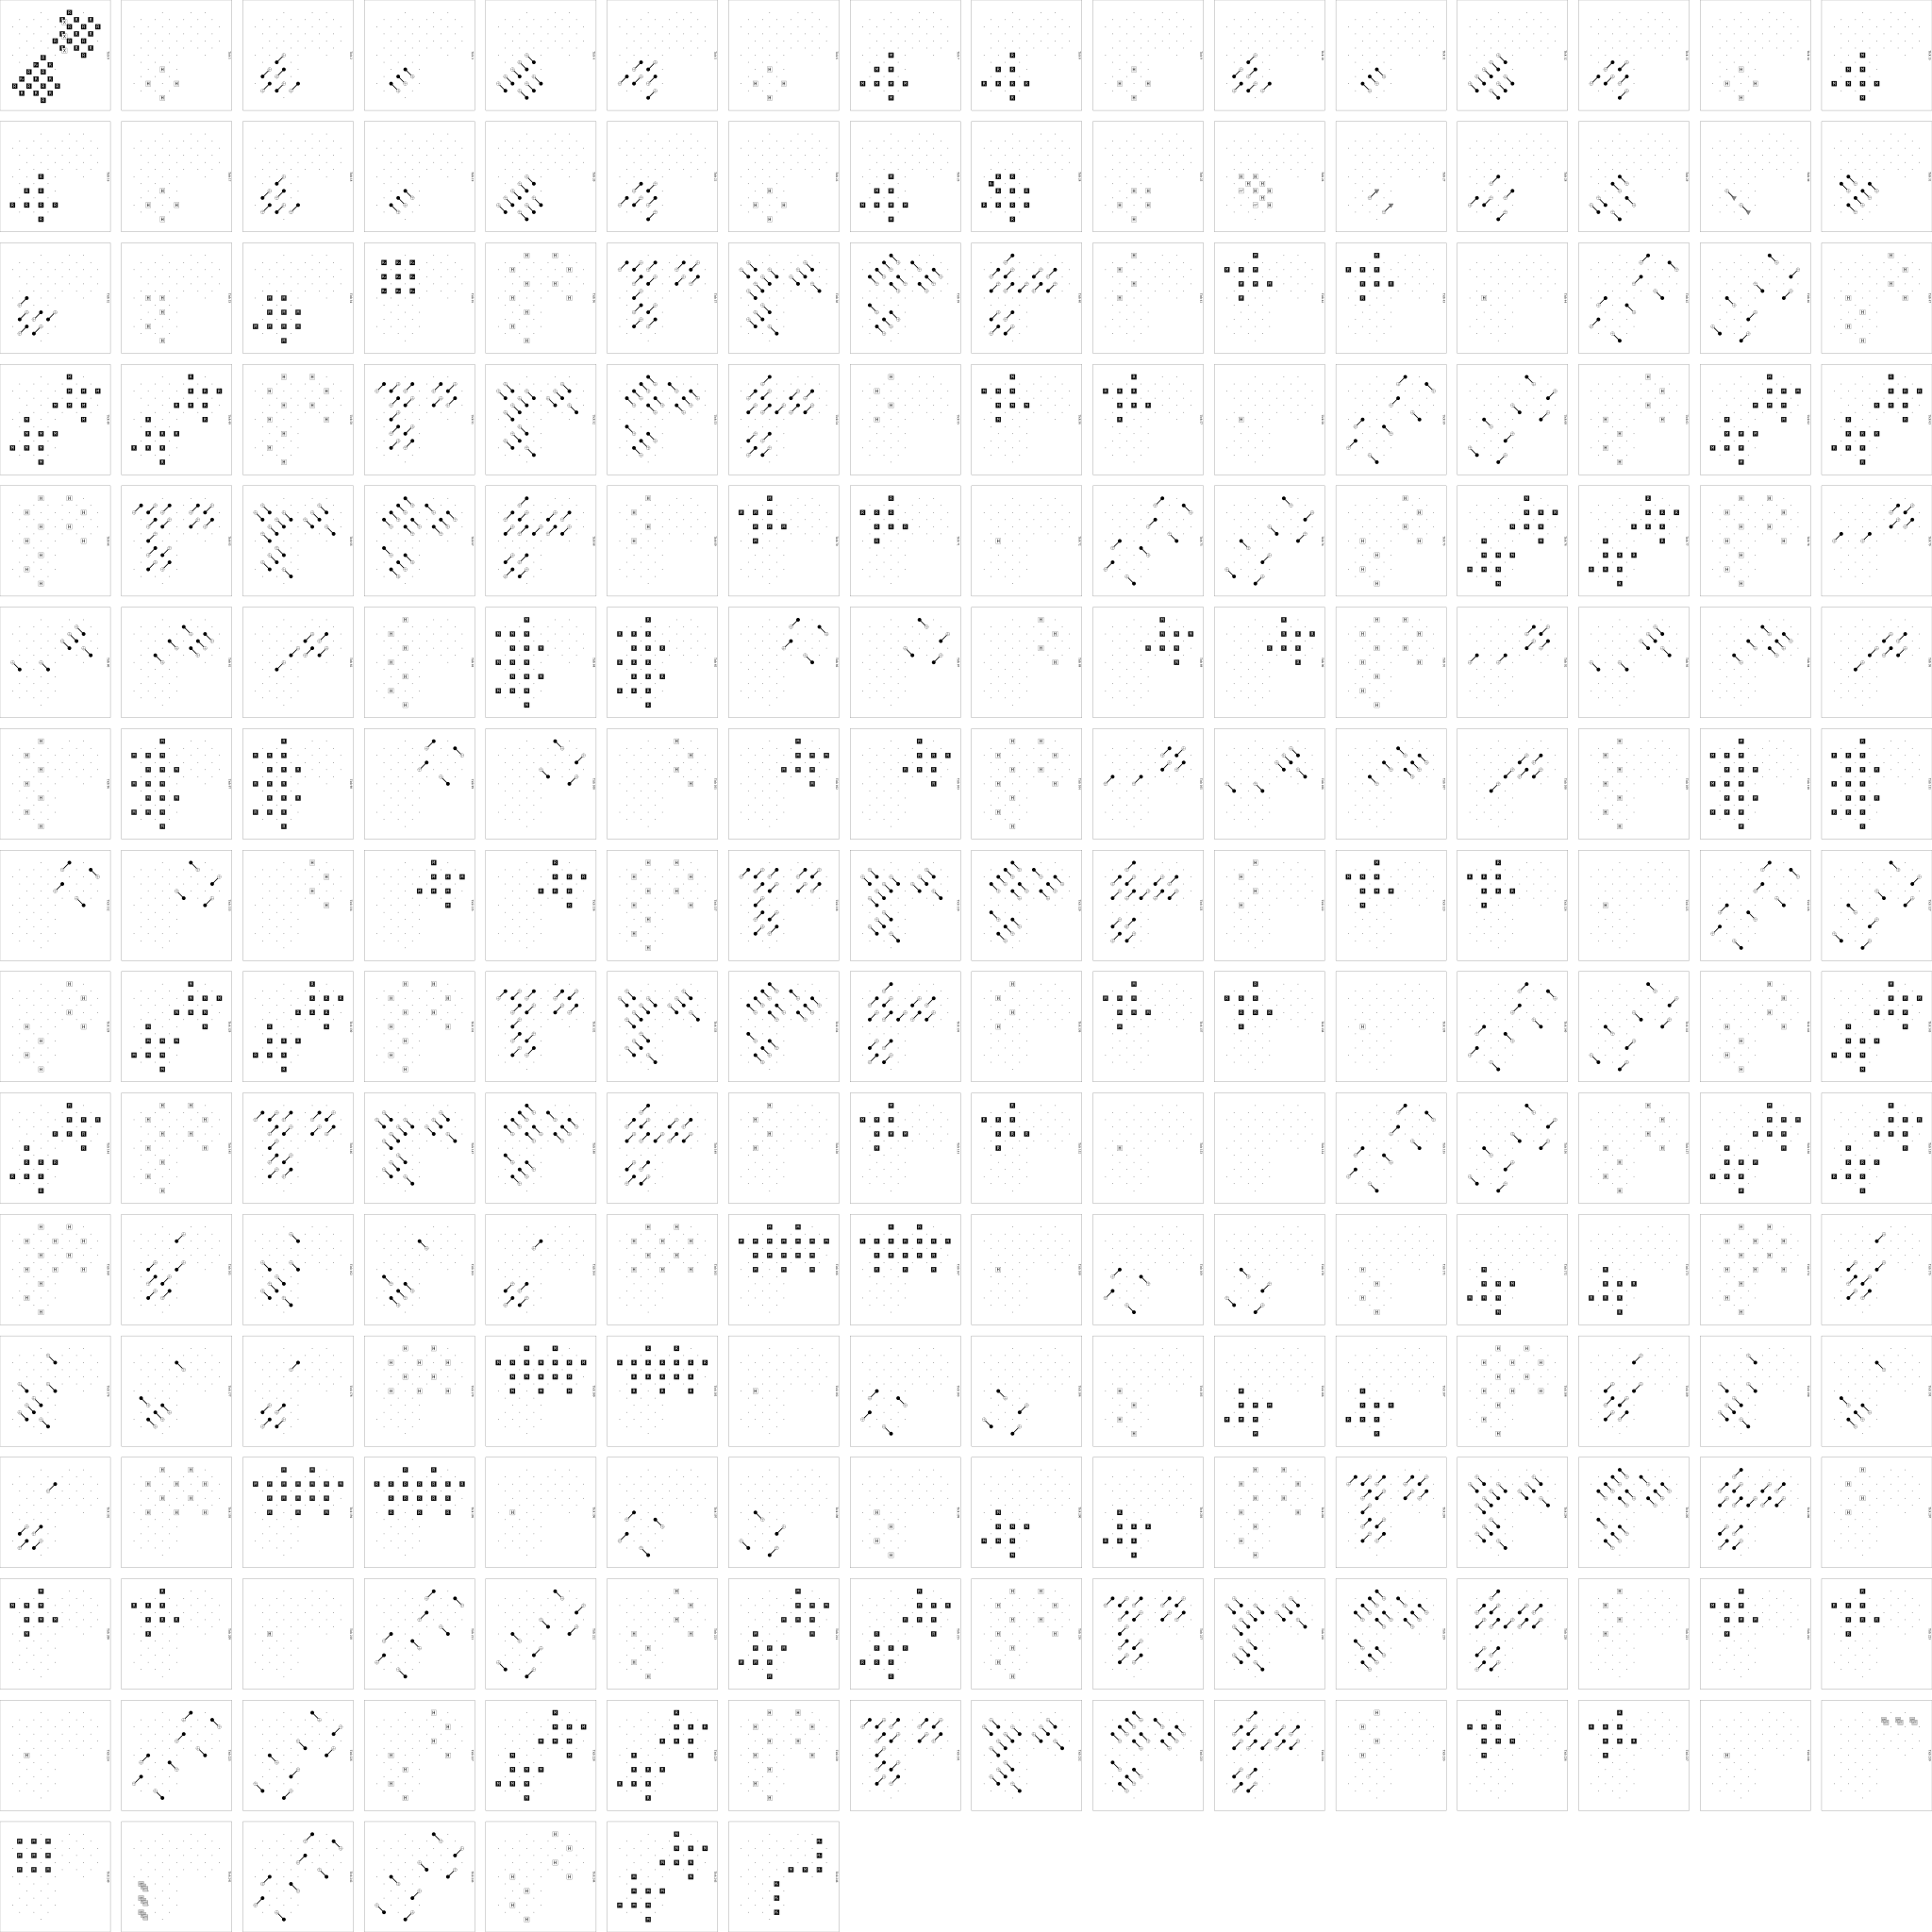

In [13]:
surgery_circuit(distance=3, target_state_init="Z1", control_state_init="Y-", flow_observable="YZ -> XY").diagram("timeslice-svg")

In [10]:
rotated_surface_code(distance= distance, 
                           rounds= distance, 
                           log_obs= "Y", 
                           state_init= "+i"
                           ).detector_error_model()

stim.DetectorErrorModel('''
    detector(4, 4, 0) D0
    detector(2, 4, 1) D1
    detector(4, 2, 1) D2
    detector(4, 6, 1) D3
    detector(6, 4, 1) D4
    detector(2, 2, 1) D5
    detector(4, 4, 1) D6
    detector(4, 0, 1) D7
    detector(0, 4, 1) D8
    detector(2, 4, 2) D9
    detector(4, 2, 2) D10
    detector(4, 6, 2) D11
    detector(6, 4, 2) D12
    detector(2, 2, 2) D13
    detector(4, 4, 2) D14
    detector(4, 0, 2) D15
    detector(0, 4, 2) D16
    detector(2, 4, 3) D17
    detector(6, 2, 3) D18
    detector(4, 6, 3) D19
    detector(6, 4, 3) D20
    detector(2, 1, 3) D21
    detector(4, 3, 3) D22
    detector(4, 0, 3) D23
    detector(0, 4, 3) D24
    detector(2, 4, 4) D25
    detector(4, 6, 4) D26
    detector(4, 2, 4) D27
    detector(0, 4, 4) D28
    detector(6, 2, 4) D29
    detector(2, 0, 4) D30
    detector(2, 2, 4) D31
    detector(4, 4, 4) D32
    shift_detectors(0, 0, 1) 0
    detector(2, 4, 0) D33
    detector(4, 2, 0) D34
    detector(4, 6, 0) D35
    detector(2,

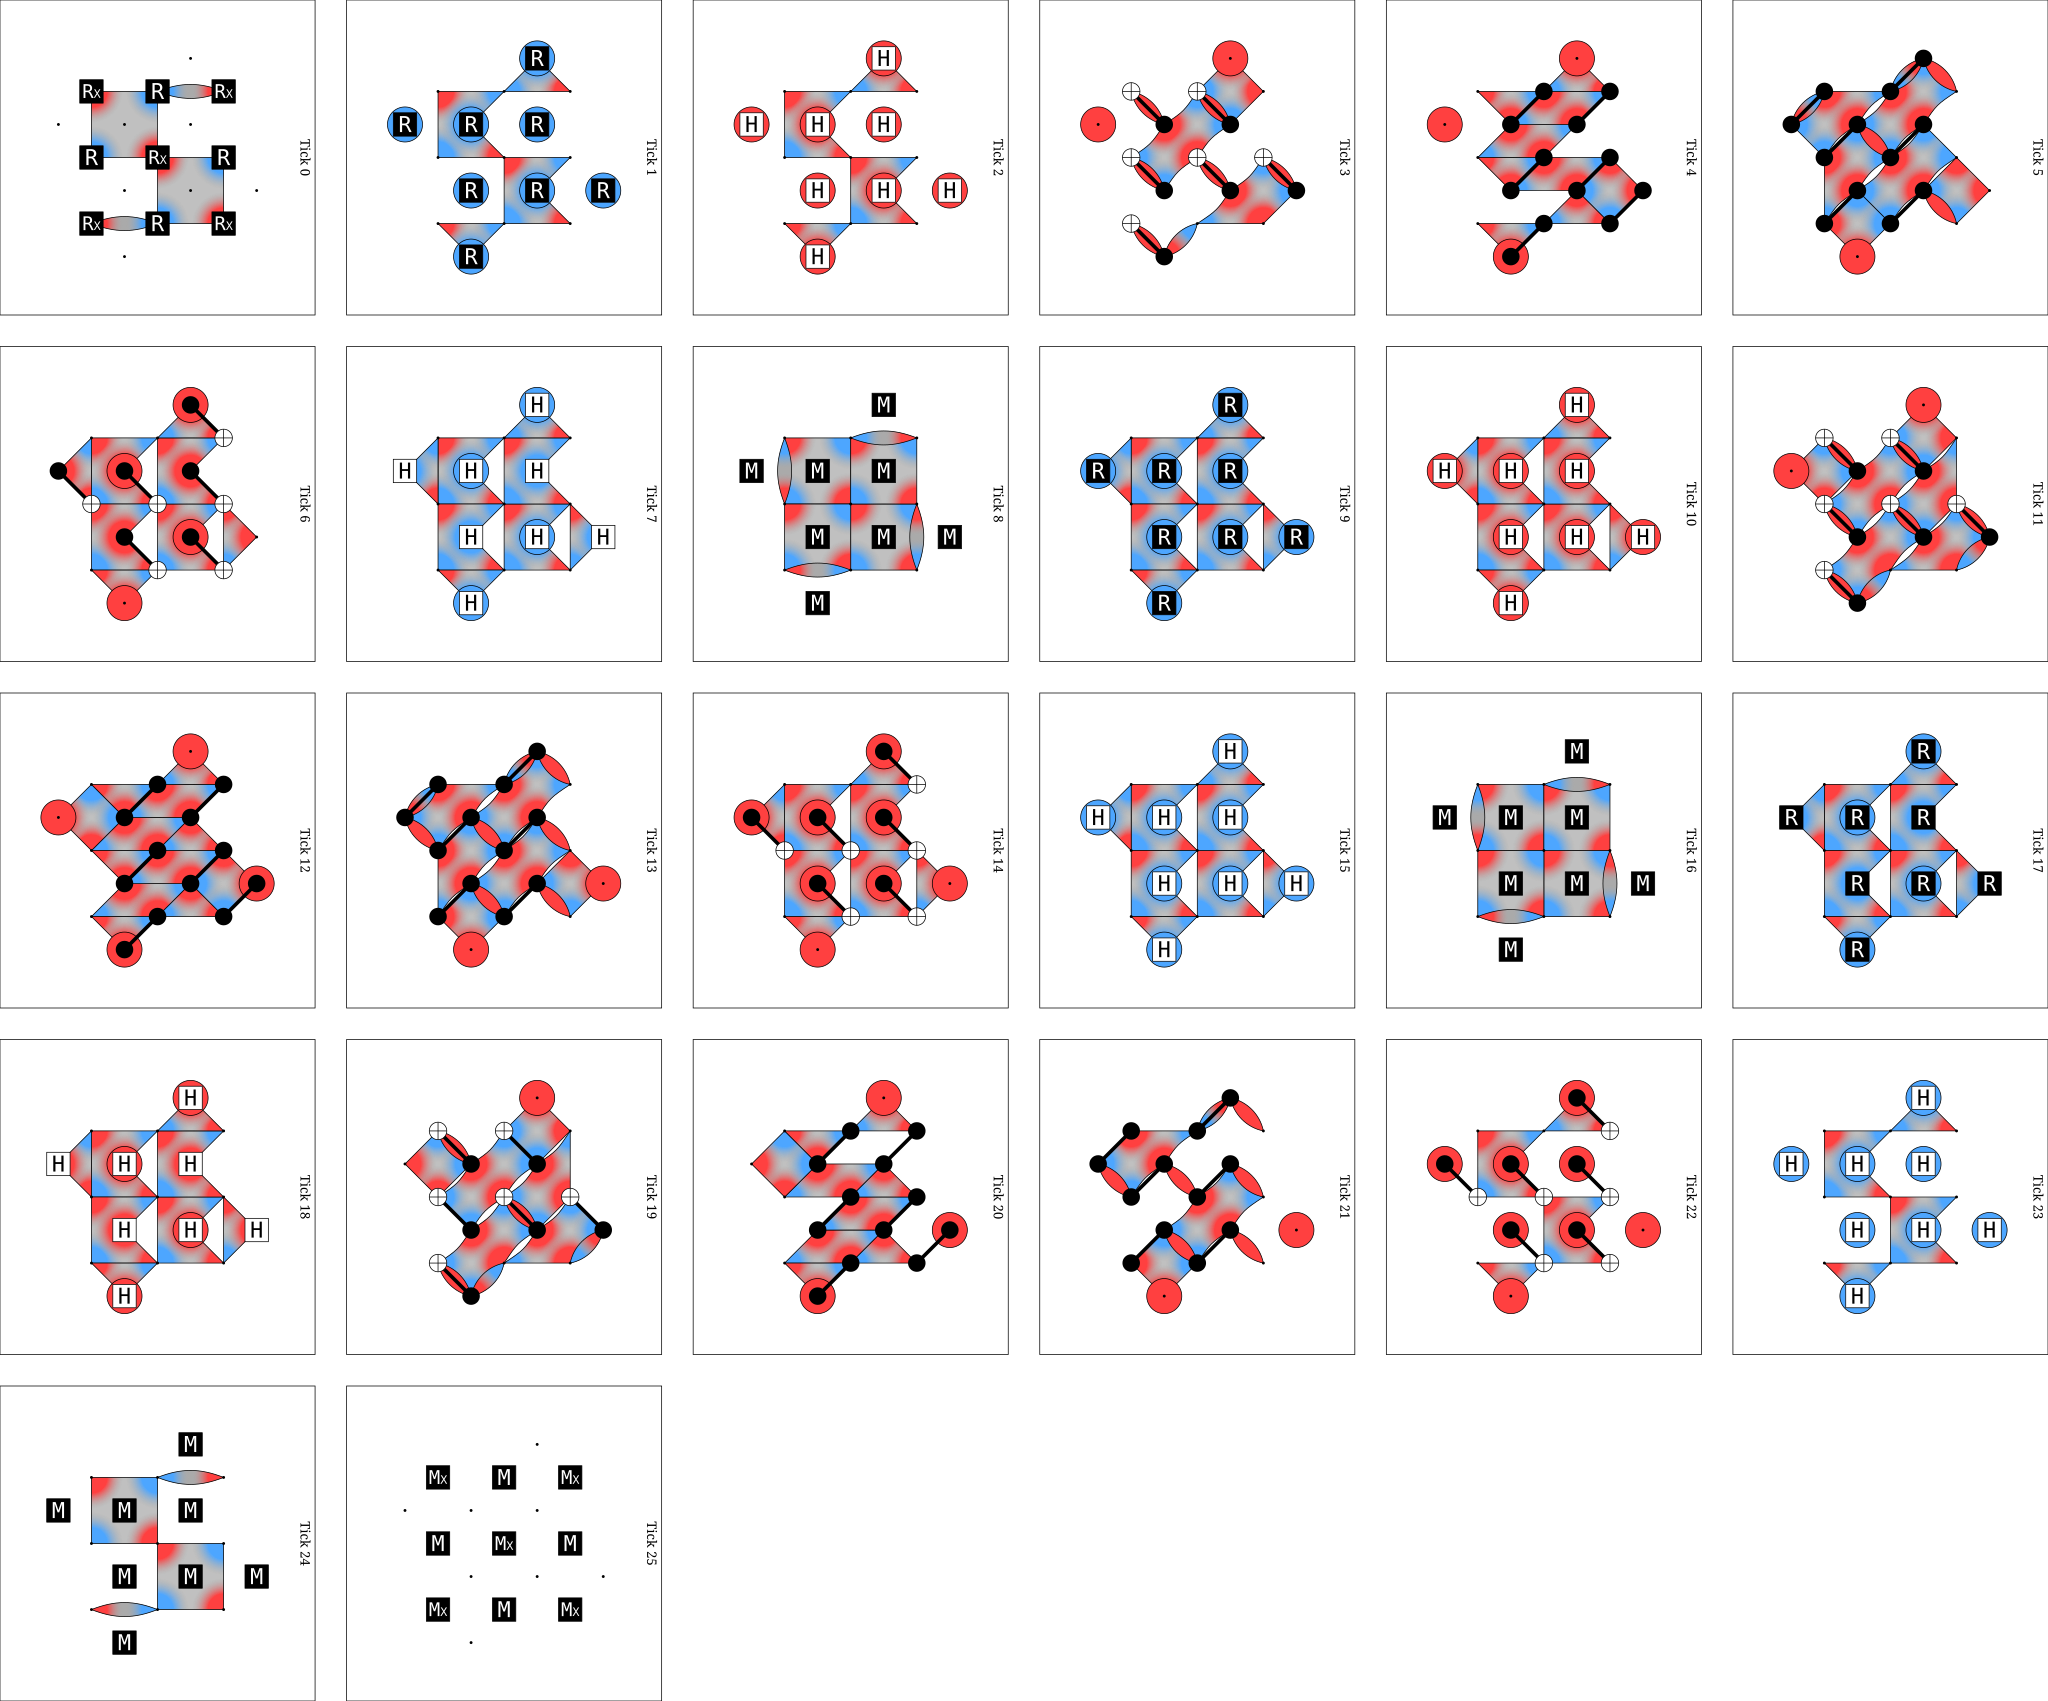

In [11]:
import stim
from src.core.cls_noise_models import CircuitNoise, BiasNoise
from src.codes.xzzx.builder import xzzx_code

noise = 0.3

test_xzzx = xzzx_code(distance=3,
                      rounds=3,
                      state_init="XZZX-VER",
                      )

test_xzzx_2 = xzzx_code(distance=3,
                      rounds=3,
                      state_init="XZZX-VER",
                      before_round_p_xyz= [0.1, 0.2, 0.3],
                      noise_bias= [1,0,0],
                      after_c_pauli_channel_prob= noise,
                      after_c_depol_prob= noise,
                      after_r_flip= noise,
                      before_m_flip_prob= noise,
                      before_round_depol= noise
                      )

test_xzzx.diagram("detslice-with-ops-svg")